<Axes: >

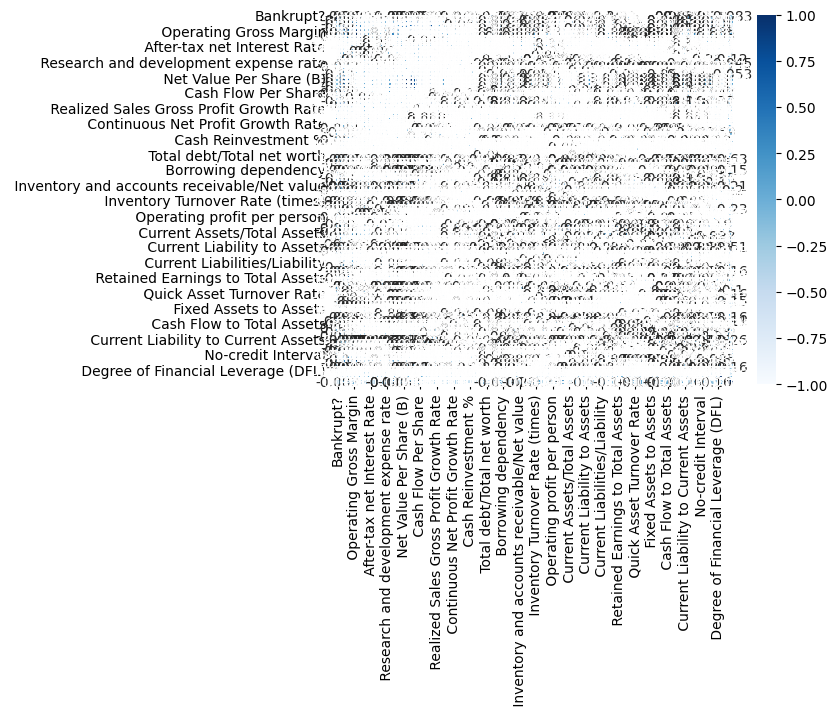

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
df = pd.read_csv('TaiwaneseData.csv')
pd.set_option('display.max_columns', None)
df.head()
correlation_matrix = df.corr()
sb.heatmap(correlation_matrix, cmap="Blues", annot=True)


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Wczytanie danych
df = pd.read_csv('TaiwaneseData.csv')

# Obliczenie macierzy korelacji
corr_matrix = df.corr()

# Wizualizacja w wysokiej rozdzielczości - tylko kolory, bez liczb
plt.figure(figsize=(16, 14), dpi=600)  # wysoka rozdzielczość
sns.heatmap(corr_matrix, 
            annot=False,  # BEZ liczb - tylko kolory
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.3,
            linecolor='white',
            cbar_kws={"shrink": 0.8, "label": "Korelacja"})

plt.title('Macierz korelacji', fontsize=18, pad=20, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# Zapisz w wysokiej rozdzielczości
plt.savefig('correlation_matrix_hd.png', dpi=600, bbox_inches='tight')
plt.show()

print(f"Macierz korelacji ma wymiary: {corr_matrix.shape}")
print(f"Wizualizacja zapisana jako 'correlation_matrix_hd.png' w rozdzielczości 600 DPI")


Macierz korelacji ma wymiary: (96, 96)
Wizualizacja zapisana jako 'correlation_matrix_hd.png' w rozdzielczości 600 DPI


In [7]:
# Stworzenie posortowanej listy najbardziej skorelowanych par zmiennych
# Wyciągnięcie górnego trójkąta macierzy (bez przekątnej)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_upper = corr_matrix.where(mask)

# Przekształcenie do listy par
correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        correlations.append({
            'Zmienna 1': corr_matrix.columns[i],
            'Zmienna 2': corr_matrix.columns[j],
            'Korelacja': corr_matrix.iloc[i, j]
        })

# Stworzenie DataFrame i posortowanie po wartości bezwzględnej korelacji
corr_df = pd.DataFrame(correlations)
corr_df['Korelacja_abs'] = corr_df['Korelacja'].abs()
corr_df_sorted = corr_df.sort_values('Korelacja_abs', ascending=False)

print("\n" + "="*80)
print("TOP 20 NAJBARDZIEJ SKORELOWANYCH PAR ZMIENNYCH:")
print("="*80)
print(corr_df_sorted[['Zmienna 1', 'Zmienna 2', 'Korelacja']].head(20).to_string(index=False))

print("\n" + "="*80)
print("TOP 10 NAJSILNIEJSZYCH KORELACJI DODATNICH:")
print("="*80)
positive_corr = corr_df_sorted[corr_df_sorted['Korelacja'] > 0].head(10)
print(positive_corr[['Zmienna 1', 'Zmienna 2', 'Korelacja']].to_string(index=False))

print("\n" + "="*80)
print("TOP 10 NAJSILNIEJSZYCH KORELACJI UJEMNYCH:")
print("="*80)
negative_corr = corr_df_sorted[corr_df_sorted['Korelacja'] < 0].head(10)
print(negative_corr[['Zmienna 1', 'Zmienna 2', 'Korelacja']].to_string(index=False))

# Zapisz do pliku CSV
corr_df_sorted[['Zmienna 1', 'Zmienna 2', 'Korelacja']].to_csv('korelacje_posortowane.csv', index=False, encoding='utf-8-sig')
print("\n✅ Pełna lista korelacji zapisana do pliku 'korelacje_posortowane.csv'")


TOP 20 NAJBARDZIEJ SKORELOWANYCH PAR ZMIENNYCH:
                                               Zmienna 1                                          Zmienna 2  Korelacja
                           Current Liabilities/Liability                     Current Liability to Liability   1.000000
                              Current Liabilities/Equity                        Current Liability to Equity   1.000000
                                            Debt ratio %                                   Net worth/Assets  -1.000000
                                  Operating Gross Margin                              Gross Profit to Sales   1.000000
                                 Net Value Per Share (A)                            Net Value Per Share (C)   0.999837
                                  Operating Gross Margin                        Realized Sales Gross Margin   0.999518
                             Realized Sales Gross Margin                              Gross Profit to Sales   0.999518

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('TaiwaneseData.csv')

# Check the target column ('Bankrupt?' - column 0)
target_col = 'Bankrupt?'
print("Class Distribution:")
print(df[target_col].value_counts(normalize=True))

# Check for missing values
if df.isnull().sum().sum() > 0:
    print("\nWarning: Missing values detected.")
else:
    print("\nData is clean of missing values.")

Class Distribution:
Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64

Data is clean of missing values.


In [ ]:
corr_matrix = df.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95 and drop them
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"Dropping {len(to_drop)} redundant features...")
df_reduced = df.drop(to_drop, axis=1)

Dropping 16 redundant features...


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define X and y
X = df_reduced.drop(target_col, axis=1)
y = df_reduced[target_col]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale the data (Fit on Train, Transform on Test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1980
           1       0.16      0.70      0.26        66

    accuracy                           0.87      2046
   macro avg       0.58      0.79      0.60      2046
weighted avg       0.96      0.87      0.91      2046

--- ROC-AUC Score ---
0.8753826140189778


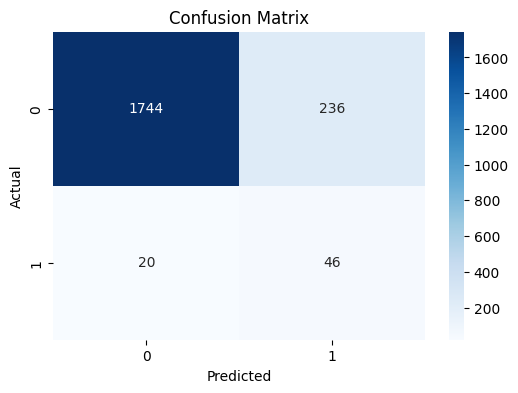

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

#Init model
logistic_regression = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

#Fit model
logistic_regression.fit(X_train_scaled, y_train)
#Predict
y_pred = logistic_regression.predict(X_test_scaled)
y_prob = logistic_regression.predict_proba(X_test_scaled)[:, 1]

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- ROC-AUC Score ---")
# AUC tells you how good the model is at distinguishing classes regardless of threshold
print(roc_auc_score(y_test, y_prob))

# Visualizing the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1980
           1       0.59      0.26      0.36        66

    accuracy                           0.97      2046
   macro avg       0.78      0.63      0.67      2046
weighted avg       0.96      0.97      0.96      2046

--- XGBoost ROC-AUC Score ---
0.9512549739822468


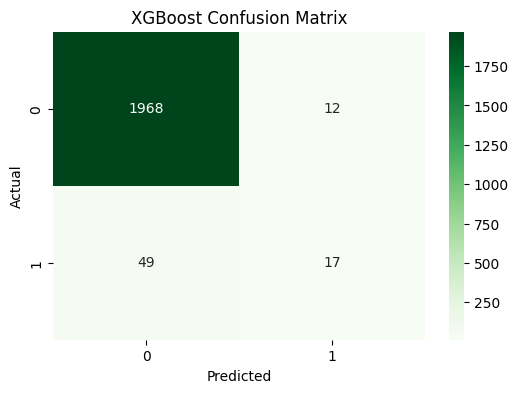

In [16]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(random_state=42, verbosity=0)
model_xgb.fit(X_train, y_train)

# Predict
y_pred = model_xgb.predict(X_test)
y_prob = model_xgb.predict_proba(X_test)[:, 1]

# Evaluate
print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred))
print("--- XGBoost ROC-AUC Score ---")
print(roc_auc_score(y_test, y_prob))
# Visualizing the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
    


--- XGBoost Classification Report (Threshold 0.15) ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1980
           1       0.47      0.59      0.52        66

    accuracy                           0.97      2046
   macro avg       0.73      0.78      0.75      2046
weighted avg       0.97      0.97      0.97      2046

--- XGBoost ROC-AUC Score ---
0.9464799510254056


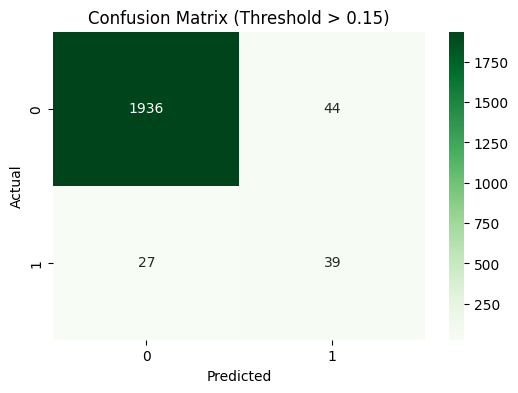

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the Ratio for the Weighting
# Formula: (Count of Healthy Companies) / (Count of Bankrupt Companies)
# In your data, this is roughly 5279 / 176 = ~30
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# 2. Initialize Model with the "Imbalance Fix"
model_xgb = XGBClassifier(
    scale_pos_weight=ratio,  # <--- CRITICAL ADDITION
    random_state=42, 
    verbosity=0,
    eval_metric='logloss'
)

model_xgb.fit(X_train, y_train)

# 3. Predict Probabilities (Not just classes)
y_prob = model_xgb.predict_proba(X_test)[:, 1]

# 4. Apply a Custom Threshold (e.g., > 10% risk = Flag as Bankrupt)
# Standard .predict() uses 0.5. We use 0.1 or 0.2 to be safer.
threshold = 0.15 
y_pred_optimized = (y_prob >= threshold).astype(int)

# 5. Evaluate
print(f"--- XGBoost Classification Report (Threshold {threshold}) ---")
print(classification_report(y_test, y_pred_optimized))

print("--- XGBoost ROC-AUC Score ---")
print(roc_auc_score(y_test, y_prob))

# Visualizing
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_optimized), annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix (Threshold > {threshold})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Liczba bankrutów przed SMOTE: 176
Liczba bankrutów po SMOTE: 5279


/Users/pawelnykiel/Documents/Studia/AnalitykaDanych/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


--- XGBoost Classification Report (Threshold 0.15) ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.50      0.52      0.51        44

    accuracy                           0.97      1364
   macro avg       0.74      0.75      0.75      1364
weighted avg       0.97      0.97      0.97      1364

--- XGBoost ROC-AUC Score ---
0.7526515151515151


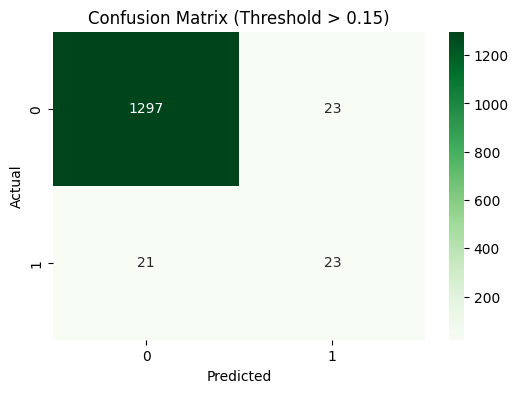

In [22]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1. Klasyczny podział (Stratified, aby zachować proporcje w teście)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Liczba bankrutów przed SMOTE: {sum(y_train == 1)}")

# 2. Zastosowanie SMOTE (Tylko na X_train!)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Liczba bankrutów po SMOTE: {sum(y_train_smote == 1)}")
# Teraz masz np. 5000 zdrowych i 5000 bankrutów w danych treningowych

# 3. Trenowanie modelu (Teraz nie musisz już używać wag/scale_pos_weight)
model = XGBClassifier(random_state=42)
model.fit(X_train_smote, y_train_smote)

# 4. Testowanie (Na oryginalnym, niezmienionym zbiorze testowym!)
y_pred = model.predict(X_test)

# 5. Evaluate
print(f"--- XGBoost Classification Report (Threshold {threshold}) ---")
print(classification_report(y_test, y_pred))

print("--- XGBoost ROC-AUC Score ---")
print(roc_auc_score(y_test, y_pred))

# Visualizing
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix (Threshold > {threshold})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

